# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

In [1]:
# Start coding here...

In [2]:
import pandas as pd
recipe_site_traffic_2212 = pd.read_csv('recipe_site_traffic_2212.csv')
recipe_site_traffic_2212.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [3]:
recipe_site_traffic_2212.dtypes

recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category         object
servings         object
high_traffic     object
dtype: object

checking for missing values

In [4]:
print(recipe_site_traffic_2212.isna().sum(), '\n', len(recipe_site_traffic_2212), '\n', recipe_site_traffic_2212.describe())

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64 
 947 
            recipe     calories  carbohydrate       sugar     protein
count  947.000000   895.000000    895.000000  895.000000  895.000000
mean   474.000000   435.939196     35.069676    9.046547   24.149296
std    273.519652   453.020997     43.949032   14.679176   36.369739
min      1.000000     0.140000      0.030000    0.010000    0.000000
25%    237.500000   110.430000      8.375000    1.690000    3.195000
50%    474.000000   288.550000     21.480000    4.550000   10.800000
75%    710.500000   597.650000     44.965000    9.800000   30.200000
max    947.000000  3633.160000    530.420000  148.750000  363.360000


                                                                                                                                                                                                                                                                                    checking for duplicate observations before solving the missing data issue

In [5]:
recipe_site_traffic_2212.duplicated().value_counts()

False    947
Name: count, dtype: int64

In [6]:
recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein']].isnull

<bound method DataFrame.isnull of      calories  carbohydrate  sugar  protein
0         NaN           NaN    NaN      NaN
1       35.48         38.56   0.66     0.92
2      914.28         42.68   3.09     2.88
3       97.03         30.56  38.63     0.02
4       27.05          1.85   0.80     0.53
..        ...           ...    ...      ...
942   1161.00          5.31  22.39    44.22
943       NaN           NaN    NaN      NaN
944    951.74         29.42   3.57    13.87
945    266.61         35.77   0.97     8.07
946    184.56         45.21   6.20     0.03

[947 rows x 4 columns]>

from the output above, missing value in one of four of calories, carbohydrate, protein and sugar hints missing value in other 3 in the row concerned.

In [7]:
recipe_site_traffic_2212 = recipe_site_traffic_2212.dropna(axis= 0, how = 'all', subset = ['calories', 'carbohydrate', 'sugar', 'protein'],)

In [8]:
recipe_site_traffic_2212.isna().sum()

recipe            0
calories          0
carbohydrate      0
sugar             0
protein           0
category          0
servings          0
high_traffic    360
dtype: int64

Bulls eye; missing in one of the column means missing in the rest of the 3 columns of the particular row. 
Dropping the affected rows seems valid

In [9]:
print(recipe_site_traffic_2212.high_traffic.value_counts(), '\n', recipe_site_traffic_2212.high_traffic.isna().sum())

high_traffic
High    535
Name: count, dtype: int64 
 360


535 values are high, the missing 360 are otherwise low as descibed in the data dictionary 

In [10]:
recipe_site_traffic_2212['high_traffic'] = recipe_site_traffic_2212['high_traffic'].fillna('low')

In [11]:
recipe_site_traffic_2212.high_traffic.value_counts()

high_traffic
High    535
low     360
Name: count, dtype: int64

from above, the null are assigned to 'low'.

In [12]:
recipe_site_traffic_2212.isna().sum()

recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64

no missng data hence a clean data.

## Data Validation
- recipe: No missing value, sequential integers. column used for recipe indexing only.
- calories: 52 null values, floating point numeric data. Cleaned by dropping null due to uniform missing values.             
- carbohydrate: 52 null values, floating point numeric data. Cleaned by dropping null due to uniform missing values.
- sugar: 52 null values, floating point numeric data. Cleaned by dropping null due to uniform missing values.
- protein: 52 null values, floating point numeric data. Cleaned by dropping null due to uniform missing values.
- category: non null, categorical fature. it will be transformed to numeric values where needed, for the classification model development using the onehot encoding.
- serving: non null, categorical fature. it will be transformed to numeric values where needed, for the classification model development using the onehot encoding.
- high_traffic: 373 initial null. few dropped by initial dropping of the nutrients' drop. the rest were inputed as 'low' as described in the data. Target value of classification model, to be transformed by the label encoder.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore

In [14]:
recipe_site_traffic_2212.servings.unique()

array(['4', '1', '2', '6', '4 as a snack', '6 as a snack'], dtype=object)

In [15]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212.servings.astype(str)

In [16]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212.servings.str.replace(' as a snack', '')

In [17]:
recipe_site_traffic_2212.servings.unique()

array(['4', '1', '2', '6'], dtype=object)

In [18]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212['servings'].astype('int64')

In [19]:
recipe_site_traffic_2212.category.unique()

array(['Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken Breast', 'Lunch/Snacks', 'Pork', 'Chicken', 'Vegetable',
       'Meat', 'Dessert'], dtype=object)

## Exploratory Data Analysis

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [21]:
le = LabelEncoder()

In [22]:
high_traffic_transf = le.fit_transform(recipe_site_traffic_2212.high_traffic)

In [23]:
type(high_traffic_transf)

numpy.ndarray

In [24]:
recipe_site_traffic_2212['high_traffic_transf'] = high_traffic_transf

In [25]:
corr_ = recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'high_traffic_transf']].corr()

<Axes: >

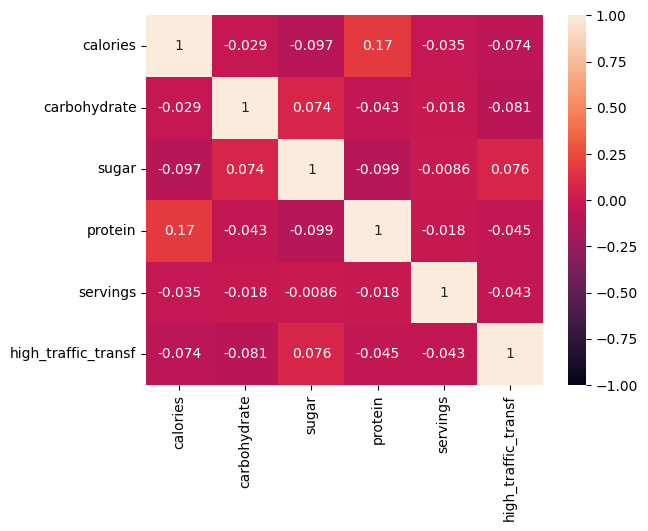

In [26]:
sns.heatmap(corr_, annot=True, vmin = -1, vmax = 1)

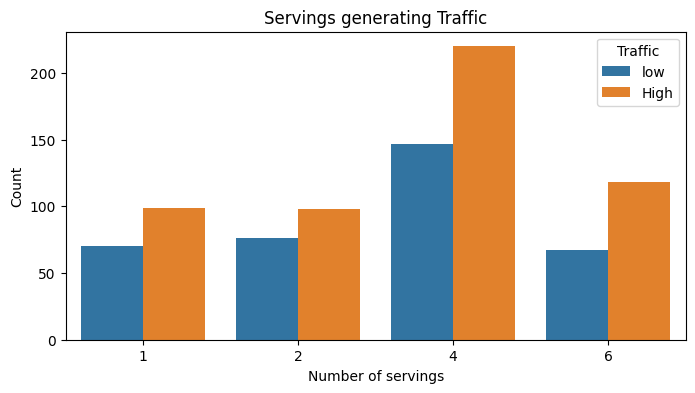

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(x='servings', hue='high_traffic', data= recipe_site_traffic_2212)
plt.title('Servings generating Traffic')
plt.xlabel('Number of servings')
plt.ylabel('Count')
plt.legend(title='Traffic')
plt.show()

In [28]:
high_traffic_cat_high = recipe_site_traffic_2212[recipe_site_traffic_2212['high_traffic']== 'High']['category']
high_traffic_cat_low = recipe_site_traffic_2212[recipe_site_traffic_2212['high_traffic']== 'low']['category']

In [29]:
high_traf_cat_high = high_traffic_cat_high.value_counts()
high_traf_cat_low = high_traffic_cat_low.value_counts()

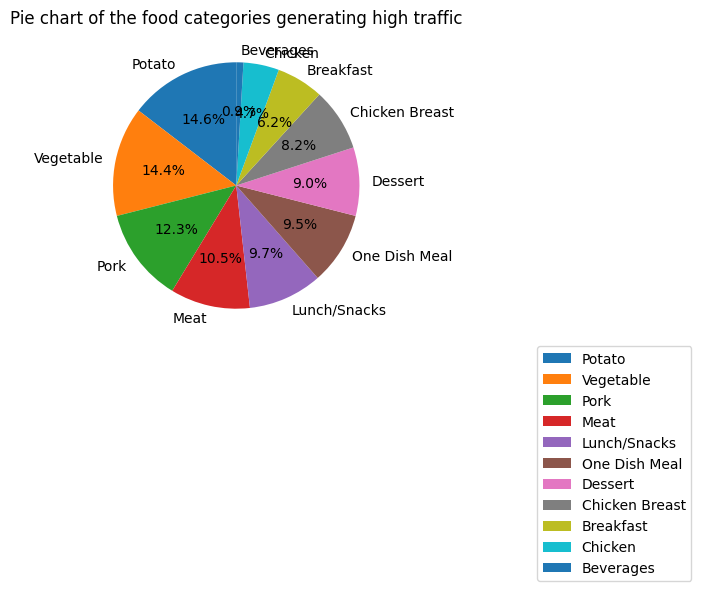

In [30]:
plt.figure(figsize=(8,4))
plt.pie(high_traf_cat_high, labels=high_traf_cat_high.index, autopct='%1.1f%%', startangle=90)
plt.title('Pie chart of the food categories generating high traffic')
plt.legend(bbox_to_anchor = (2, 0))
plt.show()


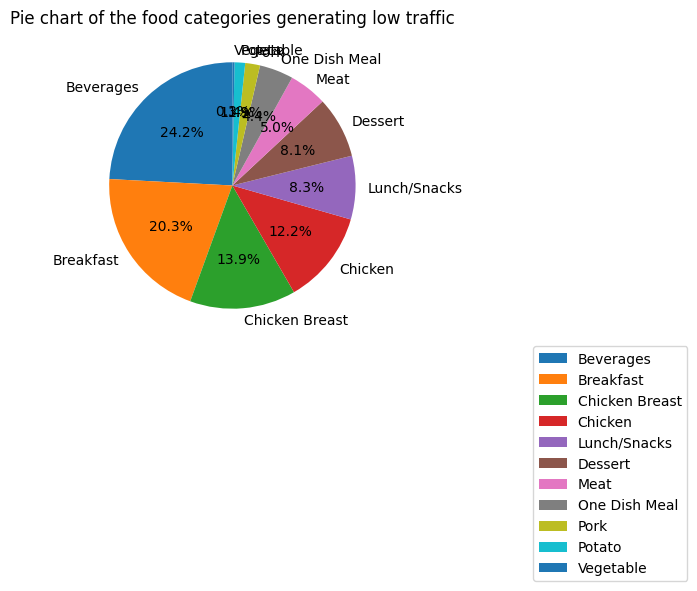

In [31]:
plt.figure(figsize=(8,4))
plt.pie(high_traf_cat_low, labels=high_traf_cat_low.index, autopct='%1.1f%%', startangle=90)
plt.title('Pie chart of the food categories generating low traffic')
plt.legend(bbox_to_anchor = (2, 0))
plt.show()


### Findings
- From the correlation heatmap, it is obvious that the nutrient features and number of servings of a recipe do not affects its traffic on the website.
  
- From the countpolt, we can conclude that the recipe with servings of 4 were mostly uploaded, over 40% the entire time. Simulteanously, the servings of 4 generated more traffic distinctly.

- From the pie charts, the food categories generating the traffic are potato, vegetable and pork totalling approximately 40% of the total traffic. Meanwhile beverages, breakfast and chicken breast are associated with the low traffic accounting for over 55% of the low traffic the entire time.

## Model Development
- This task classification task. It means predicting an outcome out of 2 or more possible outcomes. To predict if a recipe will generate traffic or not in our situation.
- The logistic regression will be employed as the base model.
- The random forest classifier will be used as the alternative model for comparison

In [32]:
recipe_site_traffic_2212.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,high_traffic_transf
1,2,35.48,38.56,0.66,0.92,Potato,4,High,0
2,3,914.28,42.68,3.09,2.88,Breakfast,1,low,1
3,4,97.03,30.56,38.63,0.02,Beverages,4,High,0
4,5,27.05,1.85,0.80,0.53,Beverages,4,low,1
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High,0


In [33]:
recipe_site_traffic_2212.dtypes

recipe                   int64
calories               float64
carbohydrate           float64
sugar                  float64
protein                float64
category                object
servings                 int64
high_traffic            object
high_traffic_transf      int64
dtype: object

In [34]:
cat_dummy = pd.get_dummies(recipe_site_traffic_2212['category'], prefix= 'cat', prefix_sep='_',
                           sparse = False, dtype=int)

In [35]:
cat_dummy.head()

,cat_Beverages,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
1,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,0


In [36]:
combined_df = pd.concat([recipe_site_traffic_2212, cat_dummy], axis =1)

In [37]:
combined_df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,high_traffic_transf,cat_Beverages,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
1,2,35.48,38.56,0.66,0.92,Potato,4,High,0,0,0,0,0,0,0,0,0,0,1,0
2,3,914.28,42.68,3.09,2.88,Breakfast,1,low,1,0,1,0,0,0,0,0,0,0,0,0
3,4,97.03,30.56,38.63,0.02,Beverages,4,High,0,1,0,0,0,0,0,0,0,0,0,0
4,5,27.05,1.85,0.80,0.53,Beverages,4,low,1,1,0,0,0,0,0,0,0,0,0,0
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High,0,0,0,0,0,0,0,0,1,0,0,0


In [38]:
print(len(combined_df), '\n', combined_df.columns)

895 
 Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic', 'high_traffic_transf', 'cat_Beverages',
       'cat_Breakfast', 'cat_Chicken', 'cat_Chicken Breast', 'cat_Dessert',
       'cat_Lunch/Snacks', 'cat_Meat', 'cat_One Dish Meal', 'cat_Pork',
       'cat_Potato', 'cat_Vegetable'],
      dtype='object')


In [39]:
X = combined_df[['calories', 'carbohydrate', 'sugar', 'protein',
       'servings', 'cat_Beverages', 'cat_Breakfast', 'cat_Chicken', 'cat_Chicken Breast', 'cat_Dessert',
       'cat_Lunch/Snacks', 'cat_Meat', 'cat_One Dish Meal', 'cat_Pork', 'cat_Potato', 'cat_Vegetable']]
y = combined_df['high_traffic_transf']

In [40]:
print(len(X), len(y), '\n', X.dtypes, '\n', y.dtypes)

895 895 
 calories              float64
carbohydrate          float64
sugar                 float64
protein               float64
servings                int64
cat_Beverages           int64
cat_Breakfast           int64
cat_Chicken             int64
cat_Chicken Breast      int64
cat_Dessert             int64
cat_Lunch/Snacks        int64
cat_Meat                int64
cat_One Dish Meal       int64
cat_Pork                int64
cat_Potato              int64
cat_Vegetable           int64
dtype: object 
 int64


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .2, random_state=12)

In [43]:
log = LogisticRegression()
log.fit(X_train, y_train.values)
log_pred = log.predict(X_test)
print(confusion_matrix(y_test, log_pred))
print('logistic f1_score', round(f1_score(y_test, log_pred), 3))
print('logistic roc auc score', round(roc_auc_score(y_test, log_pred), 3))
print('logistic_precision', round(precision_score(y_test, log_pred), 3))

[[91 21]
 [20 47]]
logistic f1_score 0.696
logistic roc auc score 0.757
logistic_precision 0.691


/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
precisions = []
f1_scores = []
roc_aucs = []
for i in range(10):
    log_rg = LogisticRegression(solver= 'liblinear',max_iter = i)
    log_rg.fit(X_train, y_train.values)
    log_pred = log_rg.predict(X_test)
    precisions.append(round(precision_score(y_test, log_pred), 3))
    f1_scores.append(round(f1_score(y_test, log_pred), 3))
    roc_aucs.append(round(roc_auc_score(y_test, log_pred), 3))
    print(confusion_matrix(y_test, log_pred), '\n')

/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

[[112   0]
 [ 67   0]] 

[[112   0]
 [ 67   0]] 

[[112   0]
 [ 67   0]] 

[[112   0]
 [ 67   0]] 



/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[[112   0]
 [ 66   1]] 

[[110   2]
 [ 64   3]] 

[[109   3]
 [ 64   3]] 

[[111   1]
 [ 65   2]] 

[[109   3]
 [ 63   4]] 

[[110   2]
 [ 65   2]] 



/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [45]:
print(precisions, '\t', f1_scores, '\t', roc_aucs)

[0.0, 0.0, 0.0, 0.0, 1.0, 0.6, 0.5, 0.667, 0.571, 0.5] 	 [0.0, 0.0, 0.0, 0.0, 0.029, 0.083, 0.082, 0.057, 0.108, 0.056] 	 [0.5, 0.5, 0.5, 0.5, 0.507, 0.513, 0.509, 0.51, 0.516, 0.506]


In [ ]:
forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train.values)
forest_pred = forest_model.predict(X_test)
print(confusion_matrix(y_test, forest_pred))
print('random forest f1_score', round(f1_score(y_test, forest_pred), 3))
print('random forest roc auc score', round(roc_auc_score(y_test, forest_pred), 3))
print('random forest precision', round(precision_score(y_test, forest_pred), 3))

[[95 17]
 [27 40]]
random forest f1_score 0.645
random forest roc auc score 0.723
random forest precision 0.702


In [ ]:
forest_precisions = []
forest_f1_scores = []
forest_roc_aucs = []
for i in range(10, 200, 20):
    forest_classifier = RandomForestClassifier(n_estimators= i, random_state= 12)
    forest_classifier.fit(X_train, y_train.values)
    forest_pred = forest_classifier.predict(X_test)
    forest_precisions.append(round(precision_score(y_test, forest_pred), 3))
    forest_f1_scores.append(round(f1_score(y_test, forest_pred), 3))
    forest_roc_aucs.append(round(roc_auc_score(y_test, forest_pred), 3))
    print(confusion_matrix(y_test, forest_pred), '\n')

[[90 22]
 [32 35]] 

[[93 19]
 [31 36]] 

[[93 19]
 [29 38]] 

[[95 17]
 [28 39]] 

[[93 19]
 [26 41]] 

[[94 18]
 [27 40]] 

[[94 18]
 [26 41]] 

[[94 18]
 [27 40]] 

[[95 17]
 [27 40]] 

[[93 19]
 [26 41]] 



In [48]:
print(forest_precisions, '\t', forest_f1_scores, '\t', forest_roc_aucs)

[0.614, 0.655, 0.667, 0.696, 0.683, 0.69, 0.695, 0.69, 0.702, 0.683] 	 [0.565, 0.59, 0.613, 0.634, 0.646, 0.64, 0.651, 0.64, 0.645, 0.646] 	 [0.663, 0.684, 0.699, 0.715, 0.721, 0.718, 0.726, 0.718, 0.723, 0.721]


## Model Evaluation
- The regular logistic regression model generated better result than its parameter-tuned counterparts, hence it adoption for comparison.
- The random forest with n_estimator paramenter of 170 and default forest model both yielded the best and equal precision and roc auc scores.

In [49]:
from sklearn.metrics import roc_curve, auc

In [50]:
#log_probs = log.predict_proba(X_test)[:, 1]
log_fpr, log_tpr, _ = roc_curve(y_test, log_pred)
log_roc_auc = auc(log_fpr, log_tpr)

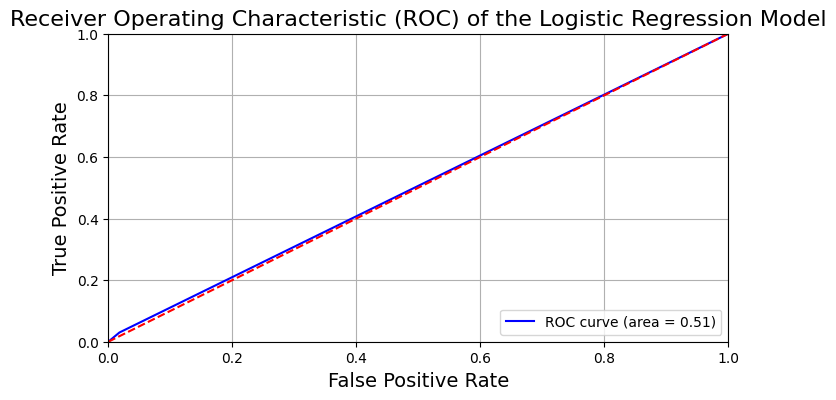

In [51]:

# Plotting ROC curve
plt.figure(figsize=(8, 4))
plt.plot(log_fpr, log_tpr, color='blue', label='ROC curve (area = %0.2f)' % log_roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) of the Logistic Regression Model', fontsize=16)
plt.legend(loc='lower right')
plt.grid()

plt.show()


In [ ]:
forest_model_best = RandomForestClassifier(n_estimators=170, random_state=12)
forest_model_best.fit(X_train, y_train.values)
forest_pred_best = forest_model_best.predict(X_test)
print(confusion_matrix(y_test, forest_pred_best))
print('random forest f1_score', round(f1_score(y_test, forest_pred_best), 3))
print('random forest roc auc score', round(roc_auc_score(y_test, forest_pred_best), 3))
print('random forest precision', round(precision_score(y_test, forest_pred_best), 3))
fpr_forest, tpr_forest, _ = roc_curve(y_test, forest_pred_best)
roc_auc = auc(fpr_forest, tpr_forest)

[[95 17]
 [27 40]]
random forest f1_score 0.645
random forest roc auc score 0.723
random forest precision 0.702


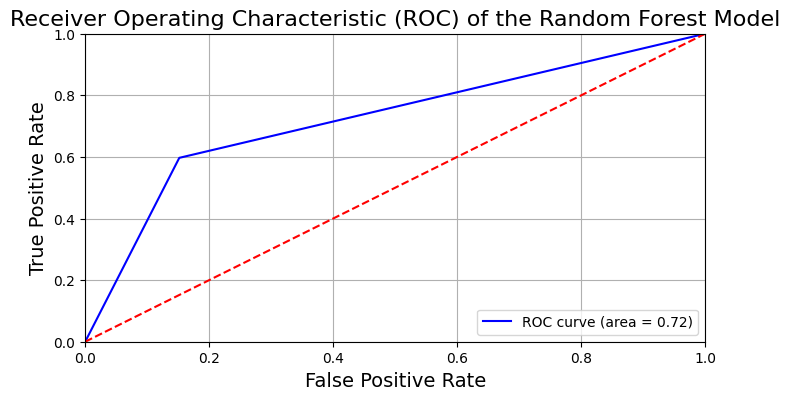

In [53]:
# Plotting ROC curve
plt.figure(figsize=(8, 4))
plt.plot(fpr_forest, tpr_forest, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) of the Random Forest Model', fontsize=16)
plt.legend(loc='lower right')
plt.grid()
plt.show()

### Model Evaluation findings
The Random Forest outperforms Logistic Regression slightly on precision metric. Most notably, the ROC-AUC score of 0.72 against 0.51 indicates that Random Forest has much better discriminative ability. Distinguishing between high and low traffic recipes much more effectively than Logistic Regression, which performs barely better than random guessing.



## Business Metric
- The product team's primary goal is to "predict which recipes will lead to high traffic also minimize the chance of showing unpopular recipes." This emphasis on avoiding unpopular recipe recommendations aligns with Precision as the key metric.  Recipes leading to high traffic are true positives while unpopular recipes classified as popular is a case of false positives, both which constitutes the precision score.
- The final precision score of 70.2% of the prediction while the initial high traffic of the original data 59.8%, meaning about 17.4% improvement but about 9% less than the desired precision from the product team.

## Final Summary and Recommendation
-  Although 80% precision was requested, the model delivers 70.2% precision, a significant 17.4% improvement over manual selection. This eliminates guesswork and provides data-driven recommendations.

- I recommend the deplyment of the random forest model while adhering to monitoring during and after the deployment. 
- I recommend collection of additional data

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation